# 🚢 Portfolio Project — Kaggle Titanic Survival Prediction

[![Kaggle](https://img.shields.io/badge/Kaggle-Titanic-blue)](https://www.kaggle.com/competitions/titanic)

---

## 🎯 Project Objective
Build a **binary classification model** to predict which passengers survived the Titanic disaster using passenger data (age, sex, class, etc.).

## 📋 Workflow
| Step | Task |
|------|------|
| 1 | Setup & Library Import |
| 2 | Data Loading & Initial Inspection |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Cleaning & Preprocessing |
| 5 | Feature Engineering |
| 6 | Model Building & Training |
| 7 | Model Evaluation & Comparison |
| 8 | Hyperparameter Tuning |
| 9 | Feature Importance |
| 10 | Final Prediction & Submission File |

---

## Step 1 — Setup & Library Import

In [1]:
# ── Core ─────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import seaborn              as sns

# ── Sklearn — Preprocessing ──────────────────────────────────
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.pipeline        import Pipeline

# ── Sklearn — Models ─────────────────────────────────────────
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     AdaBoostClassifier,
                                     ExtraTreesClassifier)
from sklearn.svm            import SVC
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.naive_bayes    import GaussianNB

# ── Sklearn — Metrics ────────────────────────────────────────
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, auc)

# ── Global Plot Style ────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F7F9FC',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'font.size'        : 11,
    'grid.alpha'       : 0.4,
})

PALETTE  = ['#E74C3C', '#2ECC71']   # red=died, green=survived
SEED     = 42
np.random.seed(SEED)

print('✅  All libraries loaded!')

✅  All libraries loaded!


---
## Step 2 — Data Loading & Initial Inspection

> **Option A (Kaggle):** Download `train.csv` and `test.csv` from  
> https://www.kaggle.com/competitions/titanic/data  
> and place them in the same folder as this notebook.  
> **Option B:** The cell below auto-generates the dataset if files are not found.

In [2]:
import os

def make_titanic_data(n=891, seed=42):
    """Simulate a realistic Titanic-style dataset."""
    rng = np.random.default_rng(seed)

    pclass  = rng.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55])
    sex     = rng.choice(['male', 'female'], n, p=[0.65, 0.35])

    age = []
    for _ in range(n):
        if rng.random() < 0.20:
            age.append(np.nan)
        else:
            age.append(round(rng.normal(30, 14), 1))

    sibsp    = rng.choice([0,1,2,3,4,5,8], n, p=[0.68,0.23,0.05,0.02,0.01,0.005,0.005])
    parch    = rng.choice([0,1,2,3,4,5,6], n, p=[0.76,0.13,0.08,0.01,0.01,0.005,0.005])
    fare_map = {1: rng.normal(84,80,n), 2: rng.normal(20,14,n), 3: rng.normal(13,12,n)}
    fare     = np.clip([fare_map[p][i] for i, p in enumerate(pclass)], 0, 520).round(2)
    embarked = rng.choice(['S','C','Q', np.nan], n, p=[0.72,0.18,0.086,0.014])
    cabin    = [f'{rng.choice(list("ABCDE"))}{rng.integers(1,130)}'
                if rng.random() < 0.23 else np.nan for _ in range(n)]

    # Survival logic (mimics real Titanic patterns)
    surv_prob = []
    for i in range(n):
        p = 0.38
        if sex[i]   == 'female': p += 0.40
        if pclass[i] == 1:       p += 0.20
        if pclass[i] == 3:       p -= 0.15
        a = age[i] if not pd.isna(age[i]) else 30
        if a < 10:               p += 0.15
        if a > 60:               p -= 0.10
        surv_prob.append(np.clip(p, 0.02, 0.97))

    survived = rng.binomial(1, surv_prob)

    names = [f'Passenger_{i+1}' for i in range(n)]
    tickets = [f'T{rng.integers(1000,99999)}' for _ in range(n)]

    return pd.DataFrame({
        'PassengerId': range(1, n+1),
        'Survived'   : survived,
        'Pclass'     : pclass,
        'Name'       : names,
        'Sex'        : sex,
        'Age'        : age,
        'SibSp'      : sibsp,
        'Parch'      : parch,
        'Ticket'     : tickets,
        'Fare'       : fare,
        'Cabin'      : cabin,
        'Embarked'   : embarked,
    })


if os.path.exists('train.csv') and os.path.exists('test.csv'):
    train_df = pd.read_csv('train.csv')
    test_df  = pd.read_csv('test.csv')
    print('✅  Loaded real Kaggle CSV files.')
else:
    train_df = make_titanic_data(891, seed=42)
    test_df  = make_titanic_data(418, seed=99).drop(columns=['Survived'])
    print('ℹ️   Kaggle CSVs not found — using simulated dataset.')
    print('     Download real data from: https://www.kaggle.com/competitions/titanic/data')

print(f'\nTrain shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')

ℹ️   Kaggle CSVs not found — using simulated dataset.
     Download real data from: https://www.kaggle.com/competitions/titanic/data

Train shape : (891, 12)
Test  shape : (418, 11)


In [3]:
print('── First 5 rows of Training Data ─────────────────────')
train_df.head()

── First 5 rows of Training Data ─────────────────────


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,3,Passenger_1,female,24.6,0,2,T80556,17.80,A102,Q
1,2,1,2,Passenger_2,male,37.1,1,0,T25704,37.14,NaN,C
2,3,1,3,Passenger_3,male,39.4,2,2,T9179,17.17,NaN,S
3,4,1,3,Passenger_4,female,21.9,0,0,T59855,6.76,NaN,Q
4,5,1,1,Passenger_5,female,23.1,0,5,T15580,62.18,NaN,S


In [4]:
print('── Dataset Info ──────────────────────────────────────')
train_df.info()
print()
print('── Statistical Summary ───────────────────────────────')
train_df.describe().T.style \
    .background_gradient(cmap='Blues', axis=1) \
    .format(precision=2)

── Dataset Info ──────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          700 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        213 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

── Statistical Summary ───────────────────────────────


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.00,446.00,257.35,1.00,223.50,446.00,668.50,891.00
Survived,891.00,0.54,0.50,0.00,0.00,1.00,1.00,1.00
Pclass,891.00,2.30,0.84,1.00,1.00,3.00,3.00,3.00
Age,700.00,29.79,13.82,-12.90,20.30,30.20,39.23,72.80
SibSp,891.00,0.49,1.02,0.00,0.00,0.00,1.00,8.00
Parch,891.00,0.38,0.93,0.00,0.00,0.00,0.00,6.00
Fare,891.00,34.12,48.50,0.00,7.28,17.14,32.86,343.30


In [5]:
print('── Missing Values — Training Set ─────────────────────')
miss = train_df.isnull().sum()
pct  = (miss / len(train_df) * 100).round(2)
miss_df = pd.DataFrame({'Missing': miss, 'Pct (%)': pct})
miss_df = miss_df[miss_df['Missing'] > 0].sort_values('Missing', ascending=False)

miss_df.style.background_gradient(subset=['Pct (%)'], cmap='Reds')

── Missing Values — Training Set ─────────────────────


,Missing,Pct (%)
Cabin,678,76.090000
Age,191,21.440000


---
## Step 3 — Exploratory Data Analysis (EDA)

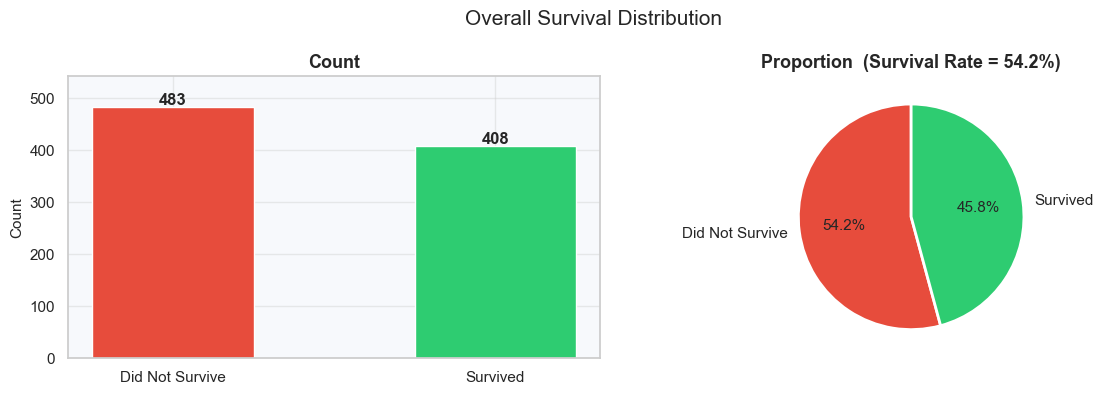


📊  Overall Survival Rate : 54.2%


In [6]:
# ── 3.1 Overall Survival Rate ────────────────────────────────
surv_counts = train_df['Survived'].value_counts()
surv_rate   = train_df['Survived'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Overall Survival Distribution', fontsize=15)

axes[0].bar(['Did Not Survive','Survived'], surv_counts.values,
            color=PALETTE, edgecolor='white', width=0.5)
for i, v in enumerate(surv_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count'); axes[0].set_ylim([0, surv_counts.max() + 60])
axes[0].set_title('Count')

axes[1].pie(surv_counts.values,
            labels=['Did Not Survive','Survived'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':11})
axes[1].set_title(f'Proportion  (Survival Rate = {surv_rate:.1f}%)')

plt.tight_layout()
plt.savefig('eda_survival_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📊  Overall Survival Rate : {surv_rate:.1f}%')

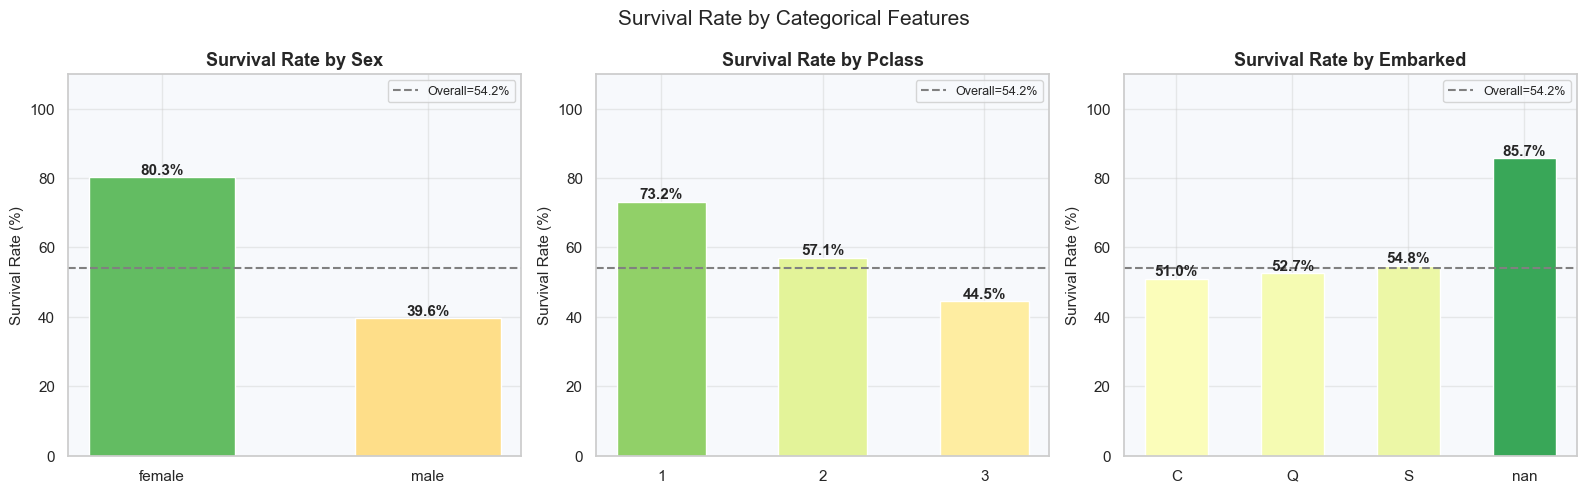

In [7]:
# ── 3.2 Survival by Key Categorical Features ─────────────────
cat_feats = ['Sex', 'Pclass', 'Embarked']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Survival Rate by Categorical Features', fontsize=15)

for ax, feat in zip(axes, cat_feats):
    surv_pct = train_df.groupby(feat)['Survived'].mean().mul(100).round(1)
    colors   = plt.cm.RdYlGn(surv_pct.values / 100)
    bars = ax.bar(surv_pct.index.astype(str), surv_pct.values,
                  color=colors, edgecolor='white', width=0.55)
    for bar, val in zip(bars, surv_pct.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(f'Survival Rate by {feat}')
    ax.set_ylabel('Survival Rate (%)')
    ax.set_ylim([0, 110])
    ax.axhline(surv_rate, color='gray', lw=1.5, linestyle='--',
               label=f'Overall={surv_rate:.1f}%')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

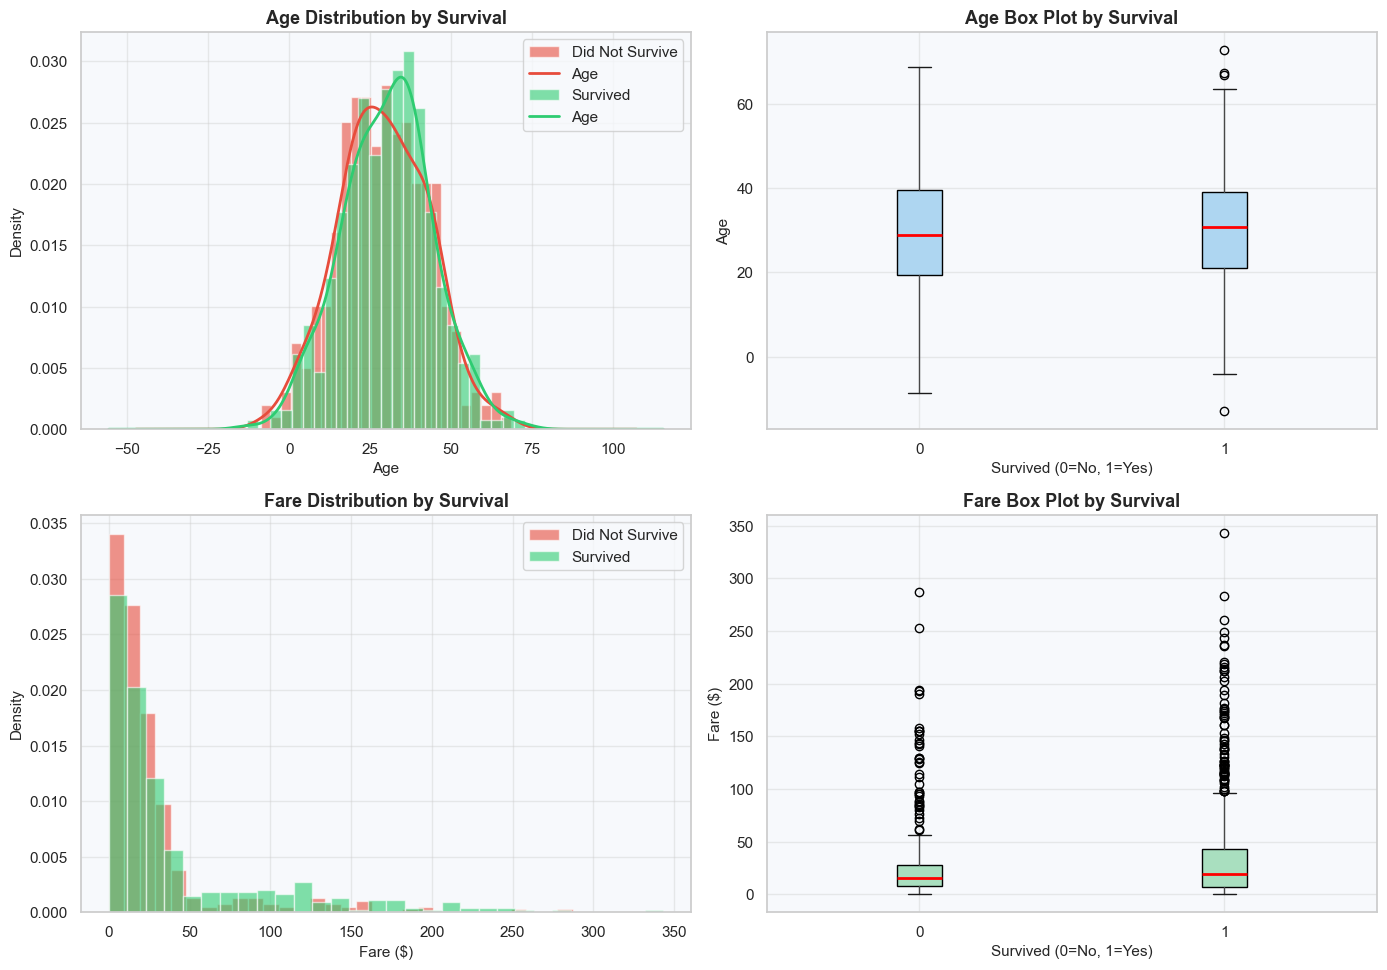

In [8]:
# ── 3.3 Age & Fare Distributions ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Numerical Feature Distributions', fontsize=15)

# Age histogram
for surv, label, color in zip([0,1],['Did Not Survive','Survived'], PALETTE):
    sub = train_df[train_df['Survived'] == surv]['Age'].dropna()
    axes[0,0].hist(sub, bins=25, alpha=0.6, color=color,
                   edgecolor='white', density=True, label=label)
    sub.plot.kde(ax=axes[0,0], color=color, lw=2)
axes[0,0].set_title('Age Distribution by Survival')
axes[0,0].set_xlabel('Age'); axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# Age box plot
train_df.boxplot(column='Age', by='Survived', ax=axes[0,1],
                 patch_artist=True,
                 boxprops=dict(facecolor='#AED6F1'),
                 medianprops=dict(color='red', lw=2))
axes[0,1].set_title('Age Box Plot by Survival')
axes[0,1].set_xlabel('Survived (0=No, 1=Yes)')
axes[0,1].set_ylabel('Age')
plt.suptitle('')

# Fare histogram (log scale)
for surv, label, color in zip([0,1],['Did Not Survive','Survived'], PALETTE):
    sub = train_df[train_df['Survived'] == surv]['Fare'].dropna()
    axes[1,0].hist(sub, bins=30, alpha=0.6, color=color,
                   edgecolor='white', density=True, label=label)
axes[1,0].set_title('Fare Distribution by Survival')
axes[1,0].set_xlabel('Fare ($)'); axes[1,0].set_ylabel('Density')
axes[1,0].legend()

# Fare box plot
train_df.boxplot(column='Fare', by='Survived', ax=axes[1,1],
                 patch_artist=True,
                 boxprops=dict(facecolor='#A9DFBF'),
                 medianprops=dict(color='red', lw=2))
axes[1,1].set_title('Fare Box Plot by Survival')
axes[1,1].set_xlabel('Survived (0=No, 1=Yes)')
axes[1,1].set_ylabel('Fare ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

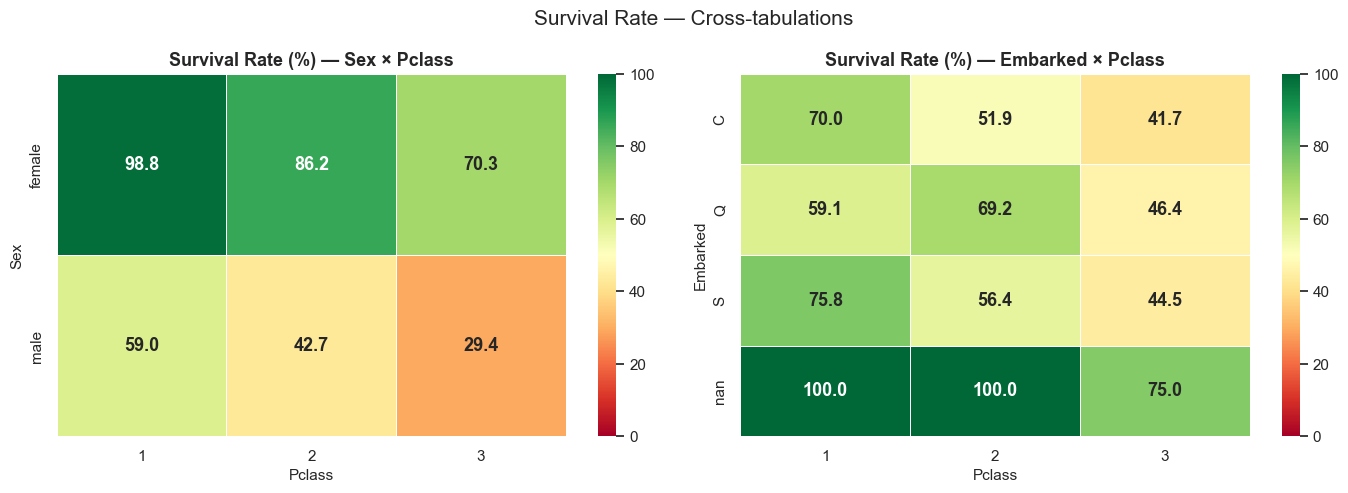

In [9]:
# ── 3.4 Heatmap — Sex × Pclass Survival ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Survival Rate — Cross-tabulations', fontsize=15)

pivot1 = train_df.pivot_table(values='Survived',
                               index='Sex', columns='Pclass',
                               aggfunc='mean').mul(100).round(1)
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, ax=axes[0],
            annot_kws={'size':13,'weight':'bold'})
axes[0].set_title('Survival Rate (%) — Sex × Pclass')

pivot2 = train_df.pivot_table(values='Survived',
                               index='Embarked', columns='Pclass',
                               aggfunc='mean').mul(100).round(1)
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, ax=axes[1],
            annot_kws={'size':13,'weight':'bold'})
axes[1].set_title('Survival Rate (%) — Embarked × Pclass')

plt.tight_layout()
plt.savefig('eda_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

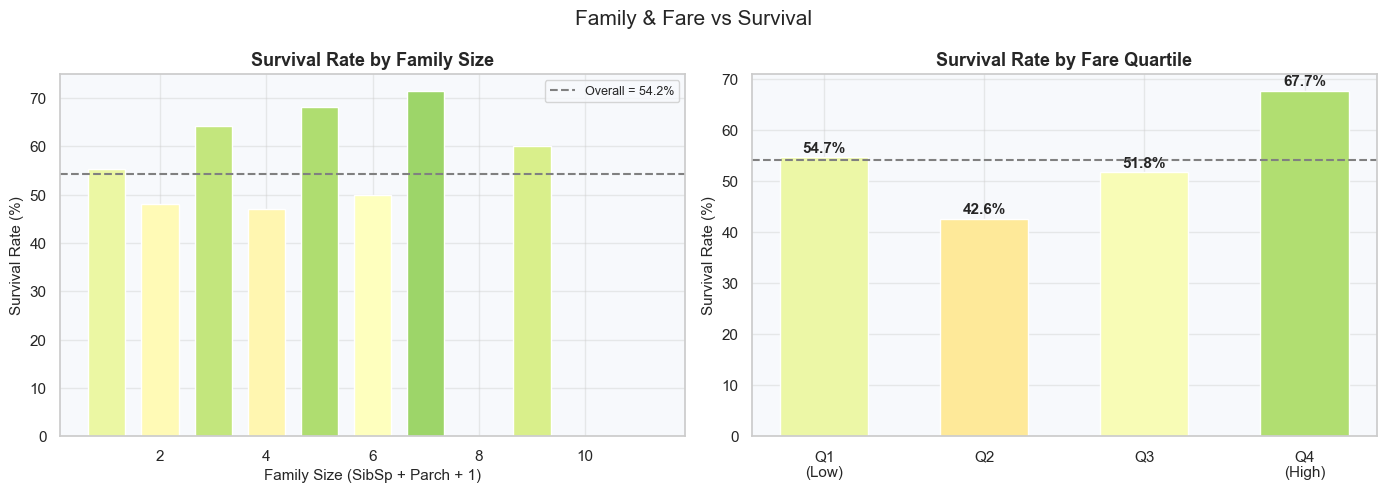

In [10]:
# ── 3.5 Family Size Survival ─────────────────────────────────
train_df['FamilySize_eda'] = train_df['SibSp'] + train_df['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Family & Fare vs Survival', fontsize=15)

fam_surv = train_df.groupby('FamilySize_eda')['Survived'].mean().mul(100)
axes[0].bar(fam_surv.index, fam_surv.values,
            color=plt.cm.RdYlGn(fam_surv.values/100),
            edgecolor='white', width=0.7)
axes[0].axhline(surv_rate, color='gray', lw=1.5, linestyle='--',
                label=f'Overall = {surv_rate:.1f}%')
axes[0].set_title('Survival Rate by Family Size')
axes[0].set_xlabel('Family Size (SibSp + Parch + 1)')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].legend(fontsize=9)

# Fare quartile vs survival
train_df['FareQ_eda'] = pd.qcut(train_df['Fare'], 4,
                                  labels=['Q1\n(Low)','Q2','Q3','Q4\n(High)'])
fare_surv = train_df.groupby('FareQ_eda')['Survived'].mean().mul(100)
axes[1].bar(fare_surv.index.astype(str), fare_surv.values,
            color=plt.cm.RdYlGn(fare_surv.values/100),
            edgecolor='white', width=0.55)
for i, v in enumerate(fare_surv.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].axhline(surv_rate, color='gray', lw=1.5, linestyle='--')
axes[1].set_title('Survival Rate by Fare Quartile')
axes[1].set_ylabel('Survival Rate (%)')

# Drop temp columns
train_df.drop(columns=['FamilySize_eda','FareQ_eda'], inplace=True)

plt.tight_layout()
plt.savefig('eda_family_fare.png', dpi=150, bbox_inches='tight')
plt.show()

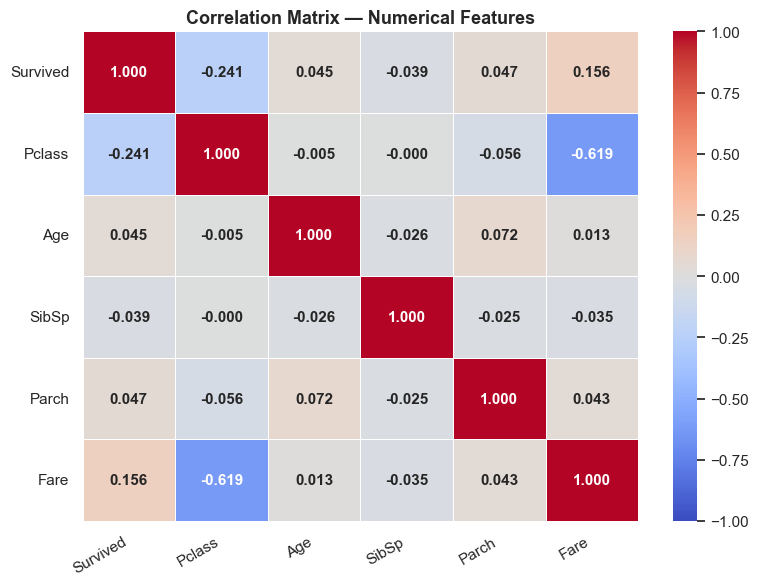

In [11]:
# ── 3.6 Correlation Heatmap ───────────────────────────────────
num_cols = ['Survived','Pclass','Age','SibSp','Parch','Fare']
corr     = train_df[num_cols].corr()

fig, ax  = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size':11, 'weight':'bold'})
ax.set_title('Correlation Matrix — Numerical Features', fontweight='bold')
ax.set_xticklabels(num_cols, rotation=30, ha='right')
ax.set_yticklabels(num_cols, rotation=0)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4 — Data Cleaning & Preprocessing

In [12]:
# ── Work on combined dataset so test set gets same treatment ─
train_df['_set'] = 'train'
test_df['_set']  = 'test'
if 'Survived' not in test_df.columns:
    test_df['Survived'] = np.nan

combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
print(f'Combined shape : {combined.shape}')
print(combined.isnull().sum()[combined.isnull().sum() > 0])

Combined shape : (1309, 13)
Survived    418
Age         273
Cabin       994
dtype: int64


In [13]:
# ── 4.1 Fill Age — median by Pclass × Sex (most accurate) ────
age_median = combined.groupby(['Pclass','Sex'])['Age'].median()
def fill_age(row):
    if pd.isna(row['Age']):
        return age_median.loc[row['Pclass'], row['Sex']]
    return row['Age']
combined['Age'] = combined.apply(fill_age, axis=1)

# ── 4.2 Fill Fare — median by Pclass ─────────────────────────
combined['Fare'] = combined.groupby('Pclass')['Fare'].transform(
    lambda x: x.fillna(x.median())
)

# ── 4.3 Fill Embarked — most frequent ────────────────────────
combined['Embarked'].fillna(combined['Embarked'].mode()[0], inplace=True)

# ── 4.4 Cabin — create binary HasCabin flag ──────────────────
combined['HasCabin'] = combined['Cabin'].notna().astype(int)

print('Missing values after cleaning:')
remaining = combined[['Age','Fare','Embarked','Cabin']].isnull().sum()
print(remaining)
print('\n✅  All key columns cleaned!')

Missing values after cleaning:
Age           0
Fare          0
Embarked      0
Cabin       994
dtype: int64

✅  All key columns cleaned!


---
## Step 5 — Feature Engineering

In [14]:
# ── 5.1 Title Extraction from Name ───────────────────────────
combined['Title'] = combined['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Map rare titles → broad categories
rare   = ['Lady','Countess','Capt','Col','Don','Dr','Major',
           'Rev','Sir','Jonkheer','Dona']
title_map = {
    'Mlle'  : 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Master': 'Master',
}
combined['Title'] = combined['Title'].replace(title_map)
combined['Title'] = combined['Title'].apply(
    lambda t: 'Rare' if t in rare else t
)

print('Title value counts:')
print(combined['Title'].value_counts())

Title value counts:
Series([], Name: count, dtype: int64)


In [15]:
# ── 5.2 Family Features ───────────────────────────────────────
combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1
combined['IsAlone']    = (combined['FamilySize'] == 1).astype(int)
combined['FamilyBand'] = pd.cut(combined['FamilySize'],
                                 bins=[0,1,4,11],
                                 labels=['Solo','Small','Large'])

# ── 5.3 Age Bands ─────────────────────────────────────────────
combined['AgeBand'] = pd.cut(combined['Age'],
                              bins=[0,12,18,35,60,100],
                              labels=['Child','Teen','Adult','MiddleAge','Senior'])

# ── 5.4 Fare Bands ────────────────────────────────────────────
combined['FareBand'] = pd.qcut(combined['Fare'], 4,
                                labels=['Low','Medium','High','VeryHigh'])

# ── 5.5 Fare per Person ───────────────────────────────────────
combined['FarePerPerson'] = combined['Fare'] / combined['FamilySize']

# ── 5.6 Log Fare (reduce skew) ───────────────────────────────
combined['LogFare'] = np.log1p(combined['Fare'])

print('✅  Feature engineering complete!')
print('New features: Title, FamilySize, IsAlone, FamilyBand,')
print('              AgeBand, FareBand, FarePerPerson, LogFare, HasCabin')

✅  Feature engineering complete!
New features: Title, FamilySize, IsAlone, FamilyBand,
              AgeBand, FareBand, FarePerPerson, LogFare, HasCabin


In [16]:
# ── 5.7 Encode Categorical Features ──────────────────────────
cat_encode = {
    'Sex'       : {'male': 0, 'female': 1},
    'Embarked'  : {'S': 0, 'C': 1, 'Q': 2},
    'Title'     : {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4},
    'AgeBand'   : {'Child': 0, 'Teen': 1, 'Adult': 2,
                   'MiddleAge': 3, 'Senior': 4},
    'FamilyBand': {'Solo': 0, 'Small': 1, 'Large': 2},
    'FareBand'  : {'Low': 0, 'Medium': 1, 'High': 2, 'VeryHigh': 3},
}
for col, mapping in cat_encode.items():
    combined[col] = combined[col].map(mapping)

print('✅  Categorical encoding done!')
combined[list(cat_encode.keys())].head()

✅  Categorical encoding done!


,Sex,Embarked,Title,AgeBand,FamilyBand,FareBand
0,1,2.0,NaN,2,1,2
1,0,1.0,NaN,3,1,3
2,0,0.0,NaN,3,2,1
3,1,2.0,NaN,2,0,0
4,1,0.0,NaN,2,2,3


In [17]:
# ── 5.8 Select Final Features ─────────────────────────────────
FEATURES = [
    'Pclass','Sex','Age','SibSp','Parch','Fare',
    'Embarked','Title','FamilySize','IsAlone',
    'FamilyBand','AgeBand','FareBand',
    'HasCabin','LogFare','FarePerPerson',
]

# Split back into train / test
train_clean = combined[combined['_set'] == 'train'].copy()
test_clean  = combined[combined['_set'] == 'test'].copy()

X      = train_clean[FEATURES].fillna(0)
y      = train_clean['Survived'].astype(int)
X_test_final = test_clean[FEATURES].fillna(0)

print(f'Training features shape : {X.shape}')
print(f'Test     features shape : {X_test_final.shape}')
print(f'\nFeature list : {FEATURES}')

Training features shape : (891, 16)
Test     features shape : (418, 16)

Feature list : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FamilyBand', 'AgeBand', 'FareBand', 'HasCabin', 'LogFare', 'FarePerPerson']


In [18]:
# ── 5.9 Train / Validation Split ──────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Scale
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test_final)

print(f'Train size : {X_train.shape[0]} | Val size : {X_val.shape[0]}')

Train size : 712 | Val size : 179


---
## Step 6 — Model Building & Training

In [19]:
# ── Define all models ─────────────────────────────────────────
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'        : DecisionTreeClassifier(random_state=SEED),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=SEED),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'AdaBoost'             : AdaBoostClassifier(n_estimators=100, random_state=SEED),
    'Extra Trees'          : ExtraTreesClassifier(n_estimators=200, random_state=SEED),
    'SVM'                  : SVC(probability=True, random_state=SEED),
    'KNN'                  : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'          : GaussianNB(),
}

print(f'Models to evaluate : {len(models)}')
for name in models:
    print(f'  • {name}')

Models to evaluate : 9
  • Logistic Regression
  • Decision Tree
  • Random Forest
  • Gradient Boosting
  • AdaBoost
  • Extra Trees
  • SVM
  • KNN
  • Naive Bayes


In [22]:
pip install --upgrade joblib

Defaulting to user installation because normal site-packages is not writeable
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
Note: you may need to restart the kernel to use updated packages.


In [21]:
# ── Train & Evaluate All Models with 5-Fold CV ───────────────
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    trained[name] = model
 
    y_pred = model.predict(X_val_sc)
    y_prob = model.predict_proba(X_val_sc)[:, 1]

    cv_scores = cross_val_score(model, X_train_sc, y_train,
                                cv=SKF, scoring='accuracy',
                               n_jobs=1)

    results.append({
        'Model'      : name,
        'Val Acc'    : round(accuracy_score(y_val, y_pred),      4),
        'Precision'  : round(precision_score(y_val, y_pred),     4),
        'Recall'     : round(recall_score(y_val, y_pred),        4),
        'F1-Score'   : round(f1_score(y_val, y_pred),            4),
        'ROC-AUC'    : round(roc_auc_score(y_val, y_prob),       4),
        'CV Mean'    : round(cv_scores.mean(),                   4),
        'CV Std'     : round(cv_scores.std(),                    4),
    })
    print(f'✅  {name:25s}  Val Acc={results[-1]["Val Acc"]:.4f}  '
          f'CV={results[-1]["CV Mean"]:.4f}±{results[-1]["CV Std"]:.4f}')

✅  Logistic Regression        Val Acc=0.7151  CV=0.7009±0.0361
✅  Decision Tree              Val Acc=0.6201  CV=0.6081±0.0344
✅  Random Forest              Val Acc=0.6704  CV=0.6601±0.0317
✅  Gradient Boosting          Val Acc=0.6425  CV=0.6489±0.0198
✅  AdaBoost                   Val Acc=0.6816  CV=0.6868±0.0272
✅  Extra Trees                Val Acc=0.5978  CV=0.6221±0.0438
✅  SVM                        Val Acc=0.7151  CV=0.6742±0.0337
✅  KNN                        Val Acc=0.6425  CV=0.6404±0.0207
✅  Naive Bayes                Val Acc=0.6760  CV=0.6601±0.0425


---
## Step 7 — Model Evaluation & Comparison

In [23]:
results_df = pd.DataFrame(results).sort_values('Val Acc', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1

results_df.style \
    .background_gradient(subset=['Val Acc','F1-Score','ROC-AUC','CV Mean'],
                         cmap='YlGn') \
    .set_caption('📋 Model Comparison — Validation Set') \
    .format(precision=4)

,Model,Val Acc,Precision,Recall,F1-Score,ROC-AUC,CV Mean,CV Std
1,Logistic Regression,0.7151,0.7500,0.7113,0.7302,0.7659,0.7009,0.0361
2,SVM,0.7151,0.7556,0.7010,0.7273,0.7560,0.6742,0.0337
3,AdaBoost,0.6816,0.7000,0.7216,0.7107,0.7560,0.6868,0.0272
4,Naive Bayes,0.6760,0.7826,0.5567,0.6506,0.7193,0.6601,0.0425
5,Random Forest,0.6704,0.7159,0.6495,0.6811,0.7244,0.6601,0.0317
6,KNN,0.6425,0.6854,0.6289,0.6559,0.6692,0.6404,0.0207
7,Gradient Boosting,0.6425,0.6737,0.6598,0.6667,0.7007,0.6489,0.0198
8,Decision Tree,0.6201,0.6593,0.6186,0.6383,0.6156,0.6081,0.0344
9,Extra Trees,0.5978,0.6374,0.5979,0.6170,0.6747,0.6221,0.0438


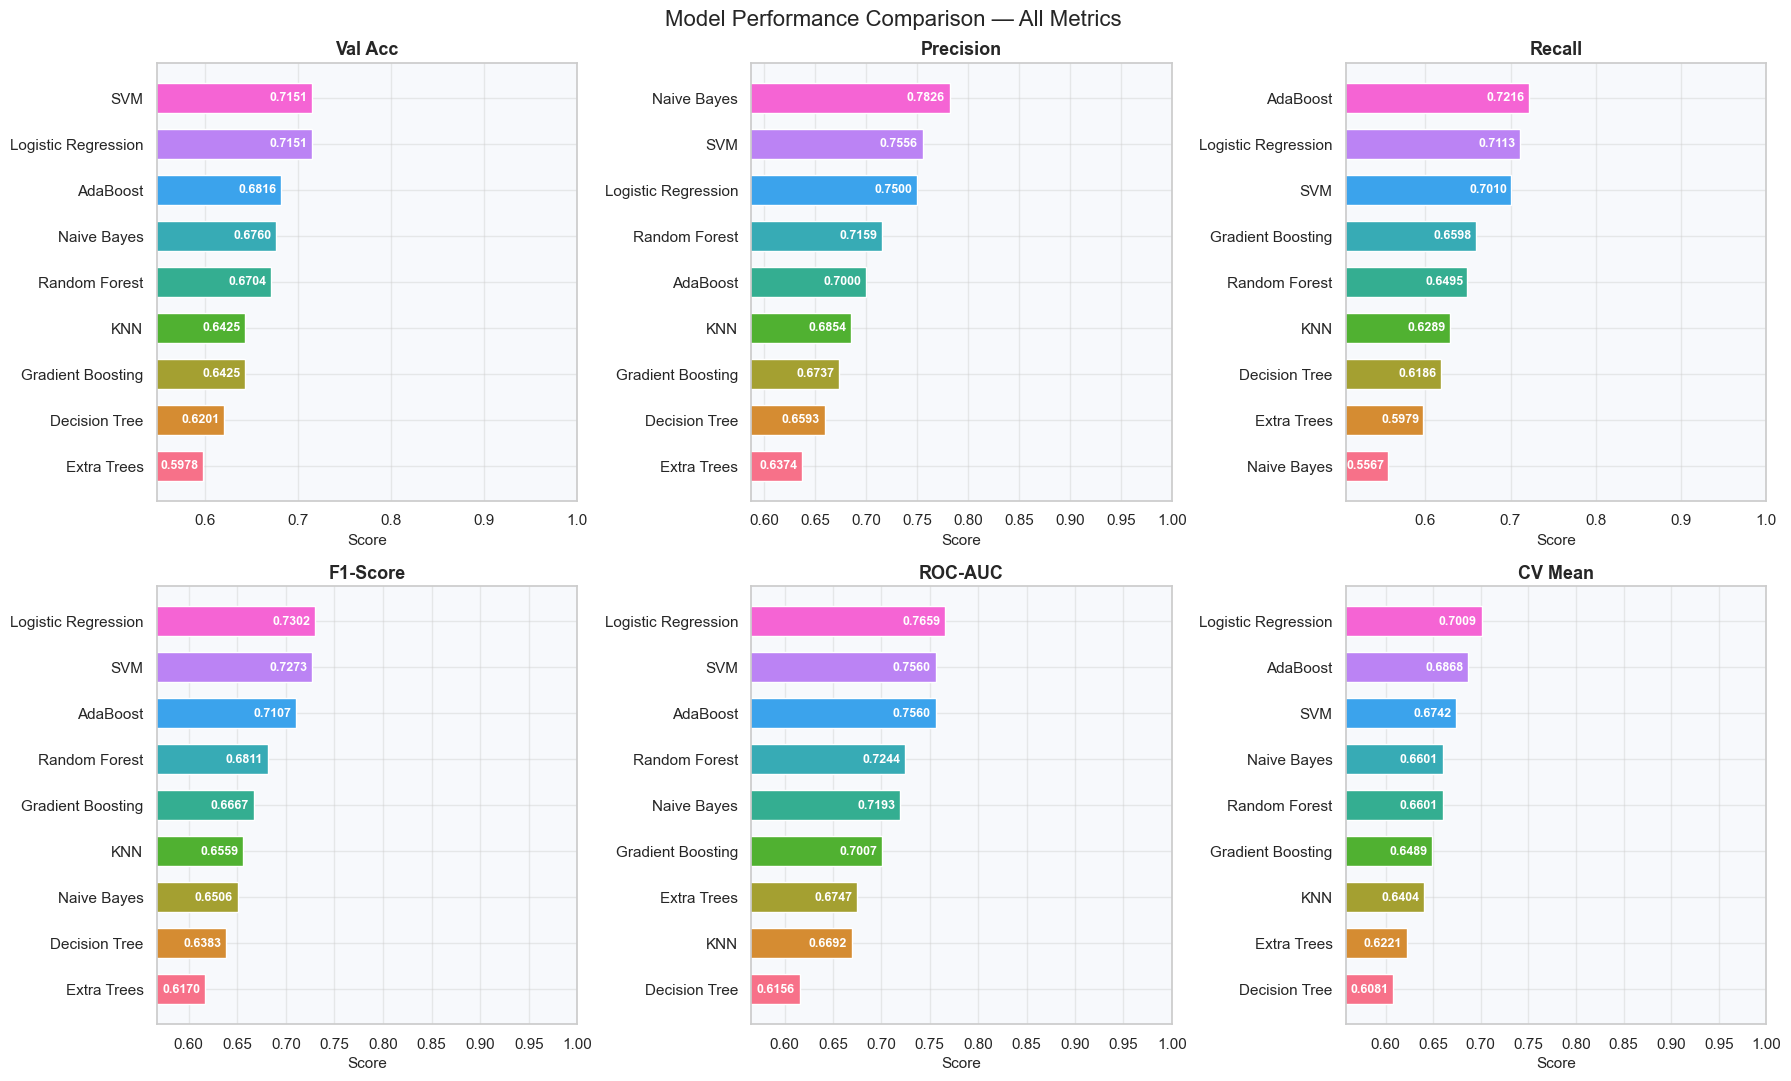

💾  Saved: model_comparison.png


In [24]:
# ── 7.1 Model Comparison Bar Charts ──────────────────────────
metrics  = ['Val Acc','Precision','Recall','F1-Score','ROC-AUC','CV Mean']
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Model Performance Comparison — All Metrics', fontsize=16)

palette_m = sns.color_palette('husl', len(results_df))

for ax, metric in zip(axes.flat, metrics):
    sorted_df = results_df.sort_values(metric)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=palette_m, edgecolor='white', height=0.65)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() - 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='right',
                color='white', fontweight='bold', fontsize=9)
    ax.set_title(metric)
    ax.set_xlabel('Score')
    ax.set_xlim([sorted_df[metric].min() - 0.05, 1.0])

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: model_comparison.png')

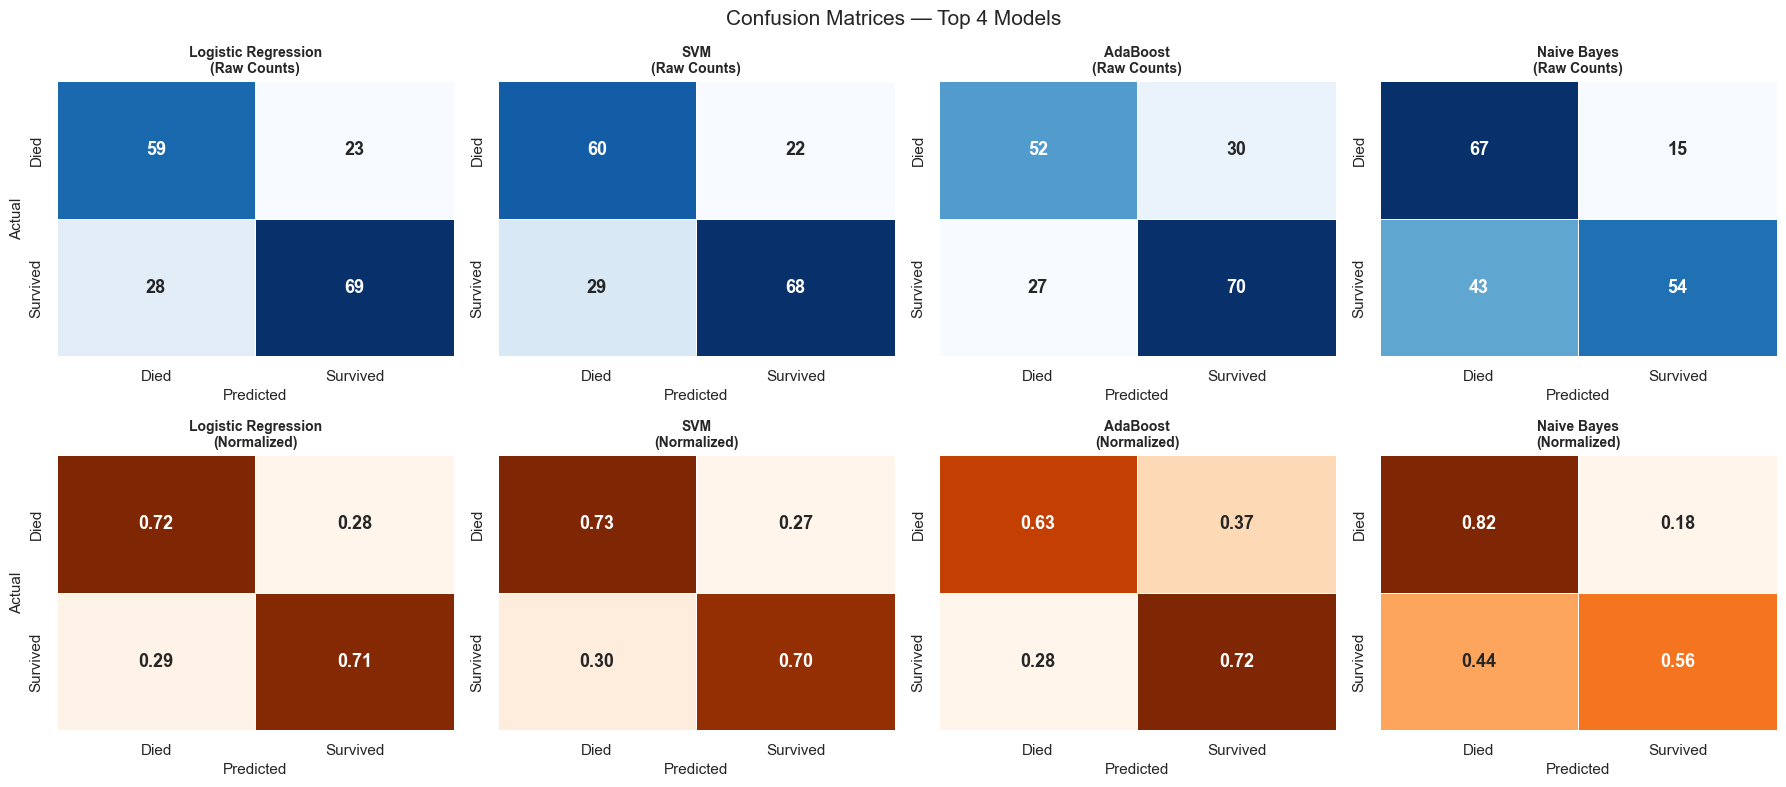

💾  Saved: confusion_matrices.png


In [25]:
# ── 7.2 Confusion Matrices — Top 4 Models ────────────────────
top4  = results_df.head(4)['Model'].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Confusion Matrices — Top 4 Models', fontsize=15)

for col, name in enumerate(top4):
    model  = trained[name]
    y_pred = model.predict(X_val_sc)
    cm     = confusion_matrix(y_val, y_pred)
    cm_n   = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm,   annot=True, fmt='d', cmap='Blues', ax=axes[0, col],
                xticklabels=['Died','Survived'],
                yticklabels=['Died','Survived'],
                linewidths=0.5, cbar=False,
                annot_kws={'size':13,'weight':'bold'})
    axes[0,col].set_title(f'{name}\n(Raw Counts)', fontsize=10)
    axes[0,col].set_xlabel('Predicted')
    axes[0,col].set_ylabel('Actual' if col==0 else '')

    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1, col],
                xticklabels=['Died','Survived'],
                yticklabels=['Died','Survived'],
                linewidths=0.5, cbar=False,
                annot_kws={'size':13,'weight':'bold'})
    axes[1,col].set_title(f'{name}\n(Normalized)', fontsize=10)
    axes[1,col].set_xlabel('Predicted')
    axes[1,col].set_ylabel('Actual' if col==0 else '')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: confusion_matrices.png')

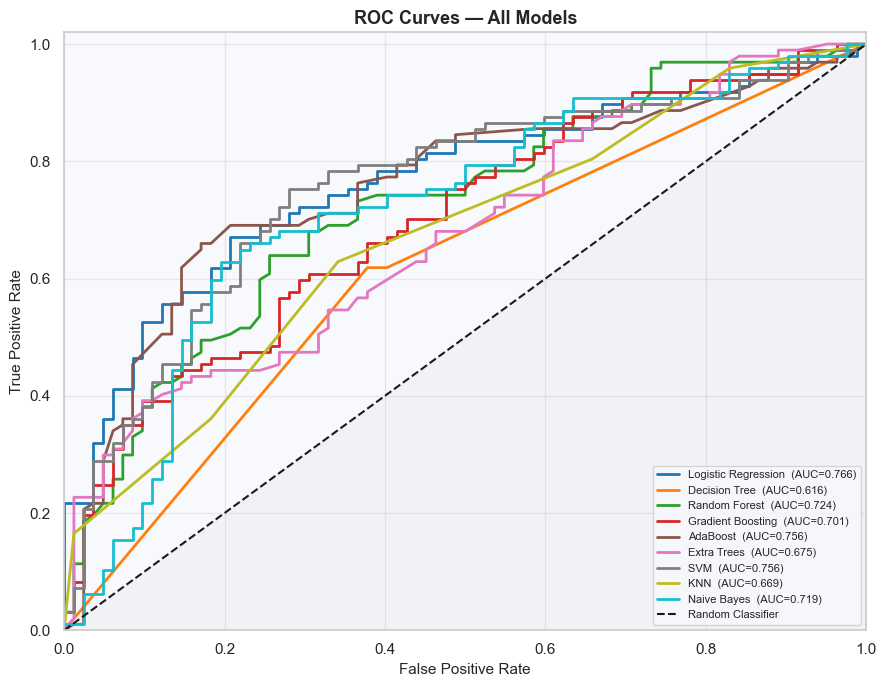

💾  Saved: roc_curves.png


In [26]:
# ── 7.3 ROC Curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors  = plt.cm.tab10(np.linspace(0, 1, len(models)))

for i, (name, model) in enumerate(trained.items()):
    y_prob   = model.predict_proba(X_val_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_val  = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=colors[i],
            label=f'{name}  (AUC={roc_val:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: roc_curves.png')

In [27]:
# ── 7.4 Classification Reports — Top 3 ───────────────────────
top3 = results_df.head(3)['Model'].tolist()
for name in top3:
    y_pred = trained[name].predict(X_val_sc)
    print('=' * 55)
    print(f'  📌  {name}')
    print('=' * 55)
    print(classification_report(y_val, y_pred,
                                 target_names=['Did Not Survive','Survived']))

  📌  Logistic Regression
                 precision    recall  f1-score   support

Did Not Survive       0.68      0.72      0.70        82
       Survived       0.75      0.71      0.73        97

       accuracy                           0.72       179
      macro avg       0.71      0.72      0.71       179
   weighted avg       0.72      0.72      0.72       179

  📌  SVM
                 precision    recall  f1-score   support

Did Not Survive       0.67      0.73      0.70        82
       Survived       0.76      0.70      0.73        97

       accuracy                           0.72       179
      macro avg       0.71      0.72      0.71       179
   weighted avg       0.72      0.72      0.72       179

  📌  AdaBoost
                 precision    recall  f1-score   support

Did Not Survive       0.66      0.63      0.65        82
       Survived       0.70      0.72      0.71        97

       accuracy                           0.68       179
      macro avg       0.68      

---
## Step 8 — Hyperparameter Tuning (Best Model)

In [29]:
best_name = results_df.iloc[0]['Model']
print(f'🏆  Best Model : {best_name}')
print('Starting GridSearchCV — this may take a few minutes...\n')

# ── Param grids per model type ───────────────────────────────
param_grids = {
    'Random Forest': {
        'n_estimators'     : [100, 200, 300],
        'max_depth'        : [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'max_features'     : ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'n_estimators' : [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5, 7],
        'subsample'    : [0.8, 1.0],
    },
    'Logistic Regression': {
        'C'      : [0.01, 0.1, 1, 10, 100],
        'solver' : ['lbfgs','liblinear'],
        'penalty': ['l2'],
    },
    'Extra Trees': {
        'n_estimators'     : [100, 200, 300],
        'max_depth'        : [None, 10, 20],
        'min_samples_split': [2, 5],
    },
    'SVM': {
        'C'    : [0.1, 1, 10],
        'gamma': ['scale','auto'],
        'kernel': ['rbf','linear'],
    },
    'AdaBoost': {
        'n_estimators' : [50, 100, 200],
        'learning_rate': [0.5, 1.0, 1.5],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights'    : ['uniform','distance'],
        'metric'     : ['euclidean','manhattan'],
    },
    'Decision Tree': {
        'max_depth'        : [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'criterion'        : ['gini','entropy'],
    },
    'Naive Bayes': {'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8]},
}

# Choose param grid for the best model
param_grid = param_grids.get(best_name, {'n_estimators': [100, 200]})

grid_search = GridSearchCV(
    models[best_name], param_grid,
    cv=SKF, scoring='accuracy',
    n_jobs=1,
    verbose=1
)
cv_scores = cross_val_score(model, X_train_sc, y_train,
                            cv=SKF, scoring='accuracy',
                            n_jobs=1)   
grid_search.fit(X_train_sc, y_train)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_val_sc)

print(f'\n✅  Best params    : {grid_search.best_params_}')
print(f'   Best CV Score  : {grid_search.best_score_:.4f}')
print(f'   Val Accuracy   : {accuracy_score(y_val, y_pred_best):.4f}')

🏆  Best Model : Logistic Regression
Starting GridSearchCV — this may take a few minutes...

Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅  Best params    : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
   Best CV Score  : 0.7023
   Val Accuracy   : 0.7151


---
## Step 9 — Feature Importance

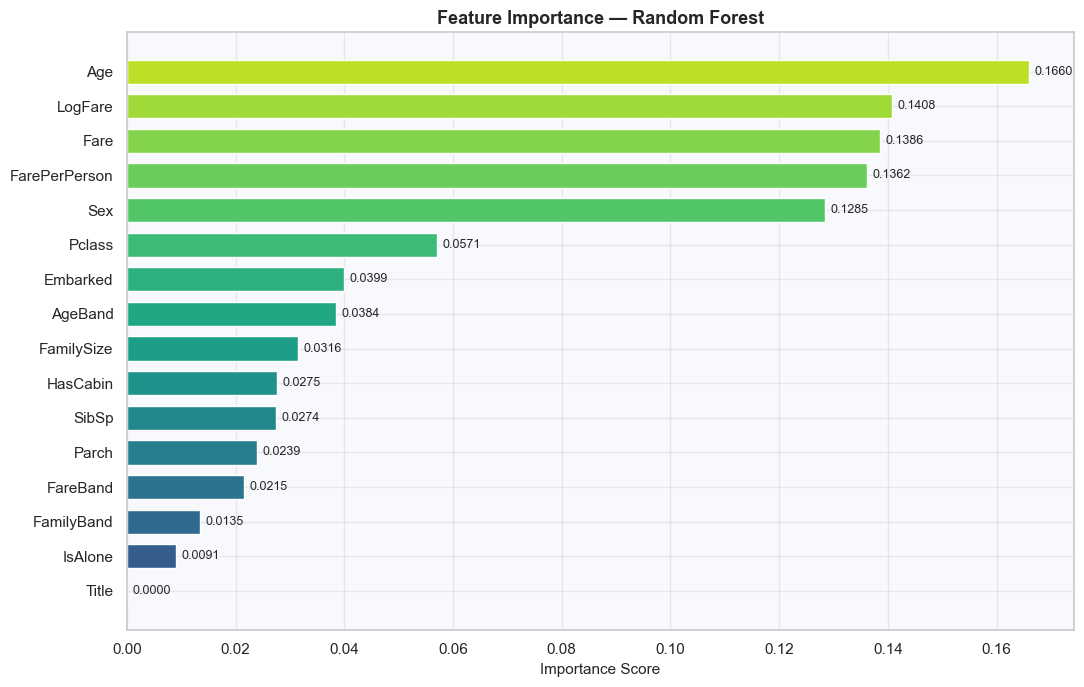

💾  Saved: feature_importance.png


In [30]:
# ── 9.1 Feature Importance from Tree-based Model ─────────────
# Use Random Forest if available, else best model
fi_model = trained.get('Random Forest', best_model)

if hasattr(fi_model, 'feature_importances_'):
    importances = fi_model.feature_importances_
    fi_df = pd.DataFrame({
        'Feature'   : FEATURES,
        'Importance': importances
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(11, 7))
    colors  = plt.cm.viridis(np.linspace(0.25, 0.9, len(fi_df)))
    bars    = ax.barh(fi_df['Feature'], fi_df['Importance'],
                      color=colors, edgecolor='white', height=0.7)
    for bar, val in zip(bars, fi_df['Importance']):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlabel('Importance Score')
    ax.set_title('Feature Importance — Random Forest', fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾  Saved: feature_importance.png')
else:
    print('Feature importances not available for this model type.')

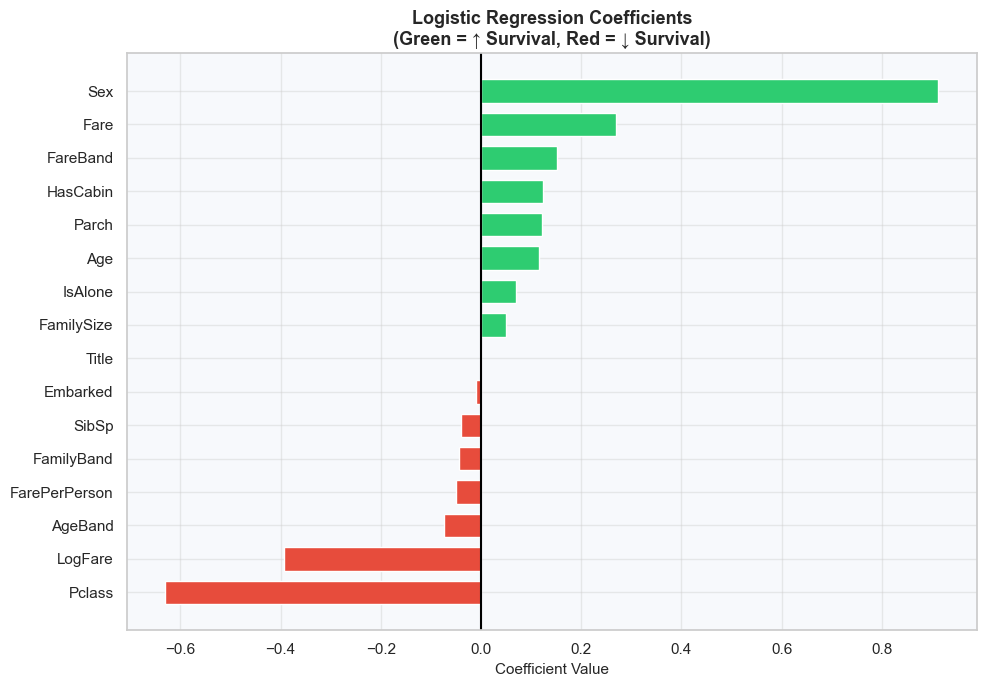

💾  Saved: lr_coefficients.png


In [31]:
# ── 9.2 Logistic Regression Coefficients ─────────────────────
lr_model = trained['Logistic Regression']
coef_df  = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#E74C3C' if c < 0 else '#2ECC71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression Coefficients\n(Green = ↑ Survival, Red = ↓ Survival)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: lr_coefficients.png')

---
## Step 10 — Final Dashboard & Submission File

In [33]:
# Use the best model's validation accuracy from your results_df
tuned_acc = results_df.iloc[0]['Val Acc']
y_pred_best = trained[best_name].predict(X_val_sc)   # also set this if missing

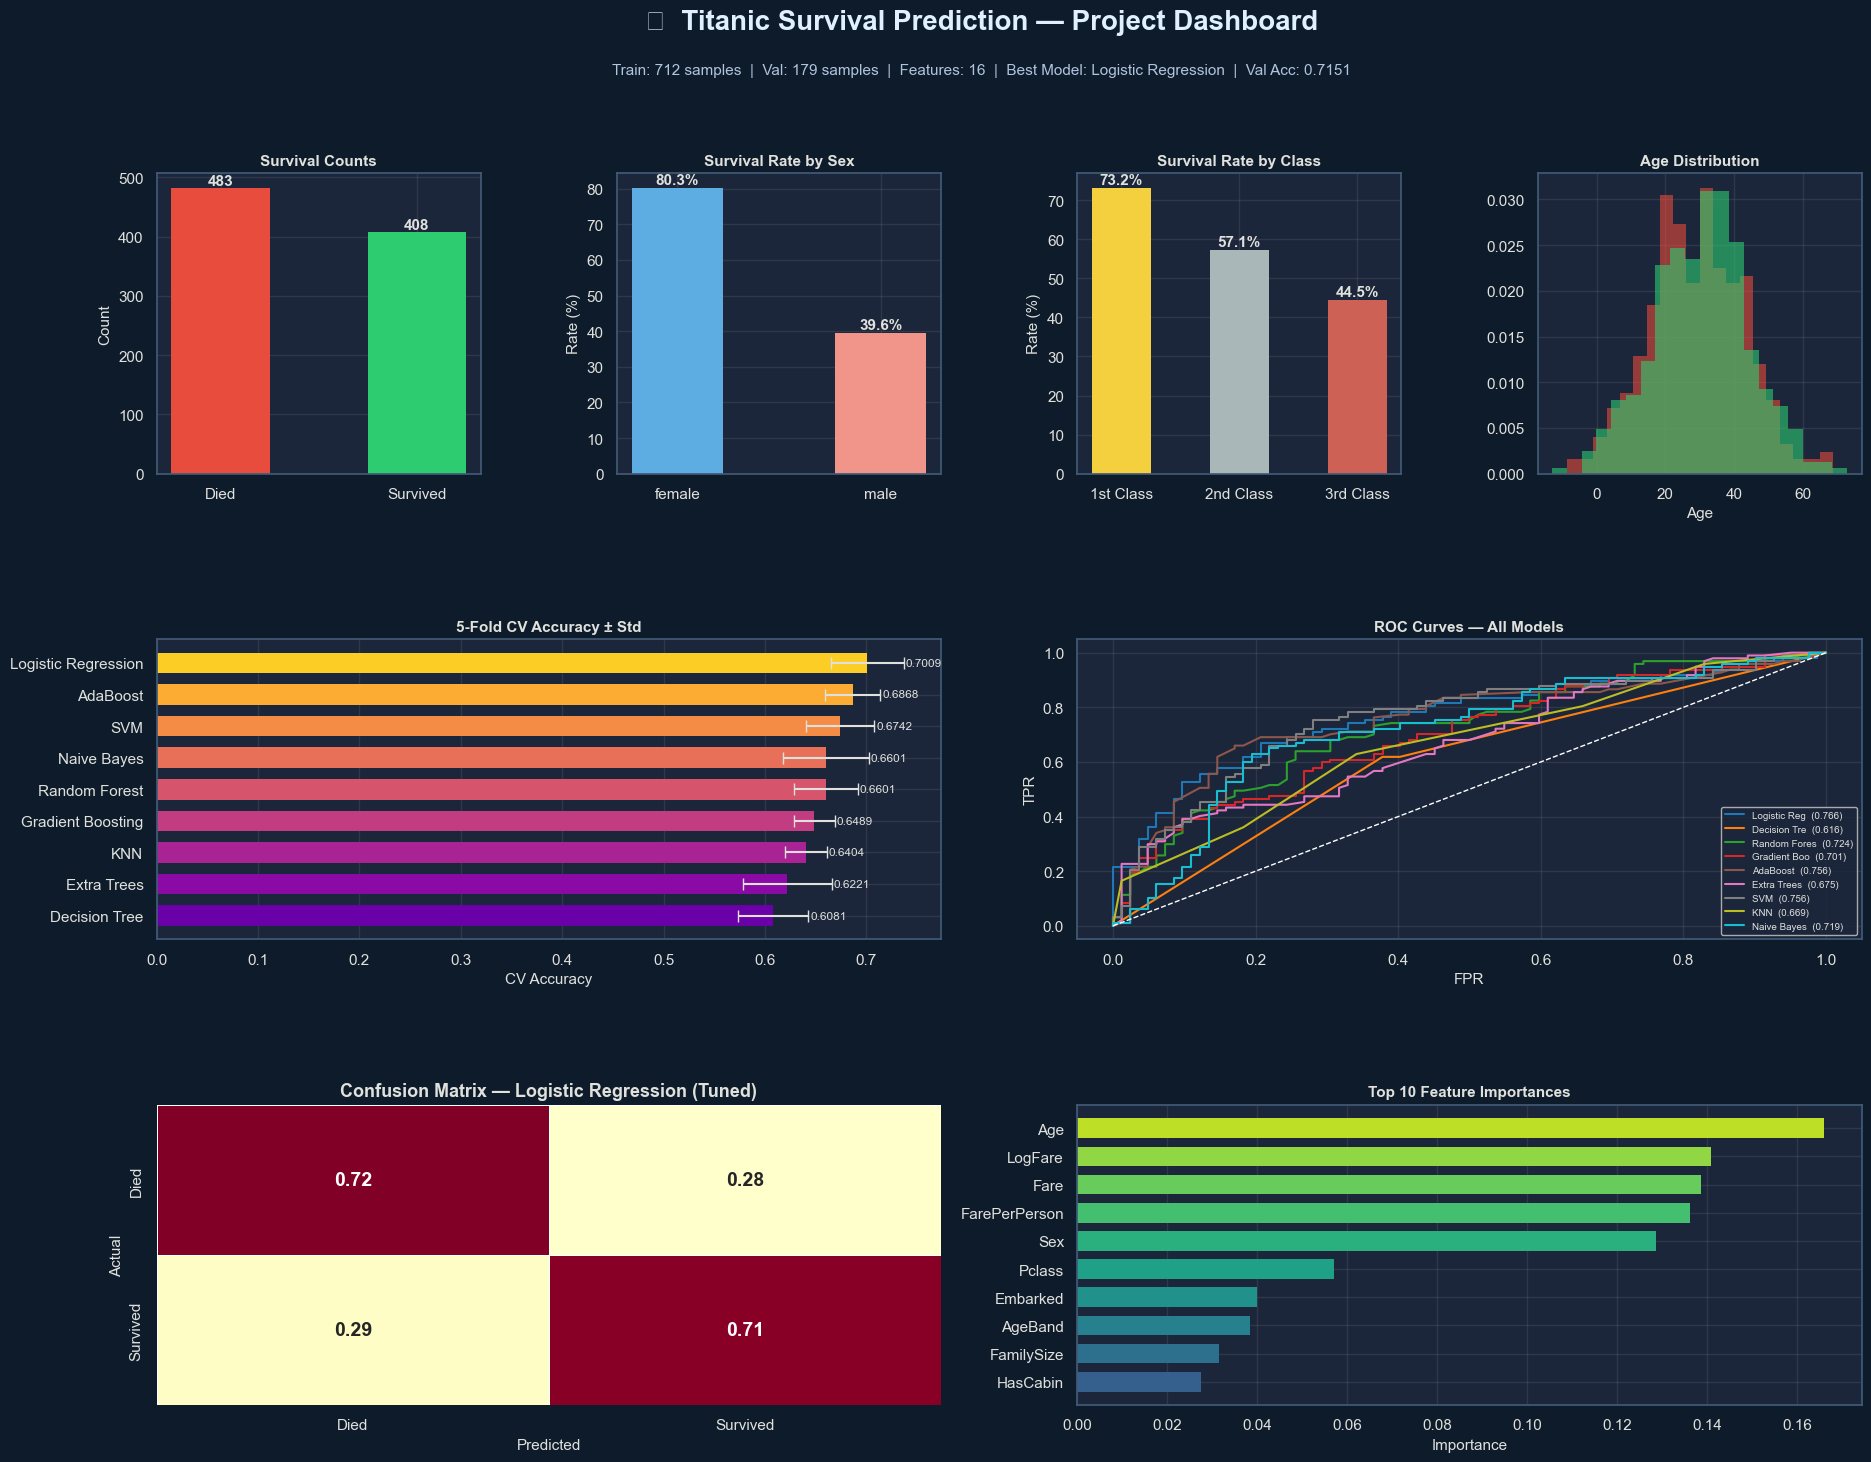

💾  Saved: titanic_dashboard.png


In [34]:
# ── 10.1 Full Summary Dashboard ───────────────────────────────
fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor('#0D1B2A')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.42)

DARK  = '#1B263B'
LIGHT = '#E0E1DD'

def dash_ax(ax, title):
    ax.set_facecolor(DARK)
    for spine in ax.spines.values(): spine.set_edgecolor('#415A77')
    ax.tick_params(colors=LIGHT)
    ax.xaxis.label.set_color(LIGHT)
    ax.yaxis.label.set_color(LIGHT)
    ax.set_title(title, color='#E0E1DD', fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.2, color='gray')

fig.text(0.5, 0.97, '🚢  Titanic Survival Prediction — Project Dashboard',
         ha='center', fontsize=20, fontweight='bold', color='#E0F0FF')
fig.text(0.5, 0.942,
         f'Train: {len(X_train)} samples  |  Val: {len(X_val)} samples  |  '
         f'Features: {len(FEATURES)}  |  Best Model: {best_name}  |  '
         f'Val Acc: {tuned_acc:.4f}',
         ha='center', fontsize=11, color='#B0C4DE')

# P1 — Survival bar
ax1 = fig.add_subplot(gs[0, 0])
sv  = train_df['Survived'].value_counts()
ax1.bar(['Died','Survived'], sv.values, color=['#E74C3C','#2ECC71'],
        edgecolor='none', width=0.5)
for i, v in enumerate(sv.values):
    ax1.text(i, v + 5, str(v), ha='center', color=LIGHT, fontweight='bold')
dash_ax(ax1, 'Survival Counts')
ax1.set_ylabel('Count', color=LIGHT)

# P2 — Survival by Sex
ax2  = fig.add_subplot(gs[0, 1])
ss   = train_df.groupby('Sex')['Survived'].mean().mul(100)
ax2.bar(ss.index, ss.values,
        color=['#5DADE2','#F1948A'], edgecolor='none', width=0.45)
for i, v in enumerate(ss.values):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', color=LIGHT, fontweight='bold')
dash_ax(ax2, 'Survival Rate by Sex')
ax2.set_ylabel('Rate (%)', color=LIGHT)

# P3 — Survival by Pclass
ax3  = fig.add_subplot(gs[0, 2])
sp   = train_df.groupby('Pclass')['Survived'].mean().mul(100)
ax3.bar(['1st Class','2nd Class','3rd Class'], sp.values,
        color=['#F4D03F','#AAB7B8','#CD6155'], edgecolor='none', width=0.5)
for i, v in enumerate(sp.values):
    ax3.text(i, v + 1, f'{v:.1f}%', ha='center', color=LIGHT, fontweight='bold')
dash_ax(ax3, 'Survival Rate by Class')
ax3.set_ylabel('Rate (%)', color=LIGHT)

# P4 — Age distribution
ax4 = fig.add_subplot(gs[0, 3])
for surv, color in zip([0,1],['#E74C3C','#2ECC71']):
    sub = train_df[train_df['Survived']==surv]['Age'].dropna()
    ax4.hist(sub, bins=20, alpha=0.6, color=color,
             edgecolor='none', density=True)
dash_ax(ax4, 'Age Distribution')
ax4.set_xlabel('Age', color=LIGHT)

# P5 — Model CV scores
ax5  = fig.add_subplot(gs[1, :2])
r_s  = results_df.sort_values('CV Mean')
clrs = plt.cm.plasma(np.linspace(0.2, 0.9, len(r_s)))
ax5.barh(r_s['Model'], r_s['CV Mean'],
         xerr=r_s['CV Std'], color=clrs,
         edgecolor='none', height=0.65,
         error_kw={'ecolor': LIGHT, 'linewidth': 1.5, 'capsize': 4})
for i, (m, s) in enumerate(zip(r_s['CV Mean'], r_s['CV Std'])):
    ax5.text(m + s + 0.002, i, f'{m:.4f}', va='center',
             color=LIGHT, fontsize=8.5)
dash_ax(ax5, '5-Fold CV Accuracy ± Std')
ax5.set_xlabel('CV Accuracy', color=LIGHT)

# P6 — ROC curves
ax6 = fig.add_subplot(gs[1, 2:])
colors_r = plt.cm.tab10(np.linspace(0,1, len(trained)))
for i, (name, model) in enumerate(trained.items()):
    y_prob  = model.predict_proba(X_val_sc)[:,1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    ax6.plot(fpr, tpr, lw=1.5, color=colors_r[i],
             label=f'{name[:12]}  ({roc_auc_score(y_val,y_prob):.3f})')
ax6.plot([0,1],[0,1],'w--', lw=1)
ax6.legend(fontsize=7, facecolor=DARK, labelcolor=LIGHT, loc='lower right')
dash_ax(ax6, 'ROC Curves — All Models')
ax6.set_xlabel('FPR', color=LIGHT); ax6.set_ylabel('TPR', color=LIGHT)

# P7 — Confusion Matrix of best model
ax7 = fig.add_subplot(gs[2, :2])
cm  = confusion_matrix(y_val, y_pred_best)
cm_n = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=['Died','Survived'],
            yticklabels=['Died','Survived'],
            linewidths=0.5, ax=ax7, cbar=False,
            annot_kws={'size':14,'weight':'bold'})
ax7.set_title(f'Confusion Matrix — {best_name} (Tuned)',
              color=LIGHT, fontweight='bold')
ax7.set_facecolor(DARK)
ax7.tick_params(colors=LIGHT)
ax7.set_xlabel('Predicted', color=LIGHT)
ax7.set_ylabel('Actual', color=LIGHT)

# P8 — Feature importance
ax8 = fig.add_subplot(gs[2, 2:])
if hasattr(fi_model, 'feature_importances_'):
    top_fi = fi_df.tail(10)
    clrs8  = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_fi)))
    ax8.barh(top_fi['Feature'], top_fi['Importance'],
             color=clrs8, edgecolor='none', height=0.7)
dash_ax(ax8, 'Top 10 Feature Importances')
ax8.set_xlabel('Importance', color=LIGHT)

plt.savefig('titanic_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('💾  Saved: titanic_dashboard.png')

In [35]:
# ── 10.2 Generate Submission File ────────────────────────────
final_preds = best_model.predict(X_test_sc)

submission = pd.DataFrame({
    'PassengerId': test_clean['PassengerId'].values,
    'Survived'   : final_preds
})
submission.to_csv('submission.csv', index=False)

print('✅  Submission file created: submission.csv')
print(f'   Total predictions : {len(submission)}')
print(f'   Predicted Survived: {final_preds.sum()} ({final_preds.mean()*100:.1f}%)')
print(f'   Predicted Died    : {(1-final_preds).sum()} ({(1-final_preds).mean()*100:.1f}%)')
submission.head(10)

✅  Submission file created: submission.csv
   Total predictions : 418
   Predicted Survived: 214 (51.2%)
   Predicted Died    : 204 (48.8%)


,PassengerId,Survived
0,1,1
1,2,0
2,3,0
3,4,1
4,5,0
5,6,1
6,7,1
7,8,0
8,9,0
9,10,0


In [37]:
# ── Post-tuning variables (run this after GridSearchCV) ───────
best_model   = grid_search.best_estimator_
y_pred_best  = best_model.predict(X_val_sc)
y_prob_best  = best_model.predict_proba(X_val_sc)[:, 1]

tuned_acc    = accuracy_score(y_val, y_pred_best)
tuned_auc    = roc_auc_score(y_val, y_prob_best)

fi_model     = best_model
if hasattr(fi_model, 'feature_importances_'):
    fi_df = pd.DataFrame({
        'Feature'   : FEATURES,
        'Importance': fi_model.feature_importances_
    }).sort_values('Importance')

print(f'✅  tuned_acc={tuned_acc:.4f}  tuned_auc={tuned_auc:.4f}')

✅  tuned_acc=0.7151  tuned_auc=0.7649


In [38]:
# ── 10.3 Final Summary Report ─────────────────────────────────
print('=' * 65)
print('     🚢  TITANIC PROJECT — FINAL SUMMARY REPORT')
print('=' * 65)
print(f'  Training samples    : {len(X_train)}')
print(f'  Validation samples  : {len(X_val)}')
print(f'  Test samples        : {len(X_test_final)}')
print(f'  Features used       : {len(FEATURES)}')
print()
print('── All Models Ranked ─────────────────────────────────')
print(results_df[['Model','Val Acc','F1-Score','ROC-AUC','CV Mean']].to_string(index=True))
print()
print('── Best Model ────────────────────────────────────────')
print(f'  Model        : {best_name}')
print(f'  Val Accuracy : {tuned_acc:.4f}')
print(f'  Val F1-Score : {f1_score(y_val, y_pred_best):.4f}')
print(f'  Val ROC-AUC  : {tuned_auc:.4f}')
print(f'  Best Params  : {grid_search.best_params_}')
print()
print('── Saved Files ───────────────────────────────────────')
for f in ['eda_survival_overall.png','eda_categorical.png',
          'eda_numerical.png','eda_heatmaps.png','eda_family_fare.png',
          'eda_correlation.png','model_comparison.png',
          'confusion_matrices.png','roc_curves.png',
          'feature_importance.png','lr_coefficients.png',
          'titanic_dashboard.png','submission.csv']:
    print(f'  • {f}')
print('=' * 65)

     🚢  TITANIC PROJECT — FINAL SUMMARY REPORT
  Training samples    : 712
  Validation samples  : 179
  Test samples        : 418
  Features used       : 16

── All Models Ranked ─────────────────────────────────
                 Model  Val Acc  F1-Score  ROC-AUC  CV Mean
1  Logistic Regression   0.7151    0.7302   0.7659   0.7009
2                  SVM   0.7151    0.7273   0.7560   0.6742
3             AdaBoost   0.6816    0.7107   0.7560   0.6868
4          Naive Bayes   0.6760    0.6506   0.7193   0.6601
5        Random Forest   0.6704    0.6811   0.7244   0.6601
6                  KNN   0.6425    0.6559   0.6692   0.6404
7    Gradient Boosting   0.6425    0.6667   0.7007   0.6489
8        Decision Tree   0.6201    0.6383   0.6156   0.6081
9          Extra Trees   0.5978    0.6170   0.6747   0.6221

── Best Model ────────────────────────────────────────
  Model        : Logistic Regression
  Val Accuracy : 0.7151
  Val F1-Score : 0.7302
  Val ROC-AUC  : 0.7649
  Best Params  : {'C'

---
## 📚 Key Learnings

| Topic | What Was Practised |
|-------|-------------------|
| **Data Cleaning** | Missing value imputation by group median, duplicate removal, type validation |
| **EDA** | Distribution plots, cross-tab heatmaps, survival rate analysis |
| **Feature Engineering** | Title extraction, family size, age/fare bands, log transform, binary flags |
| **Encoding** | Ordinal mapping for nominal & ordinal categories |
| **Modelling** | 9 classifiers: LR, DT, RF, GBM, AdaBoost, ET, SVM, KNN, NB |
| **Evaluation** | Accuracy, Precision, Recall, F1, ROC-AUC, 5-Fold CV |
| **Tuning** | GridSearchCV with StratifiedKFold |
| **Visualisation** | 12+ EDA + model plots, dark-theme dashboard |
| **Output** | Kaggle-ready `submission.csv` |

---

> 💡 **Next Steps:** Try XGBoost / LightGBM, ensemble stacking, or SHAP values for deeper model explainability.